<a href="https://colab.research.google.com/github/Prithviraj108/walmart-sales-forecasting/blob/main/Walmart_sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


In [29]:
## Load Dataset

import kagglehub, os

path = kagglehub.dataset_download("aslanahmedov/walmart-sales-forecast")
print("Path to dataset files:", path)
print("\nFiles available:", os.listdir(path))

Using Colab cache for faster access to the 'walmart-sales-forecast' dataset.
Path to dataset files: /kaggle/input/walmart-sales-forecast

Files available: ['features.csv', 'stores.csv', 'train.csv', 'test.csv']


In [30]:
csv_file_path = os.path.join(path, 'train.csv')
df = pd.read_csv(csv_file_path)
df['Date'] = pd.to_datetime(df['Date'])

print('Shape:', df.shape)
df.head()

Shape: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [31]:
## Data Exploration & Preprocessing

print(df.dtypes)
print('\nDate range:', df['Date'].min(), 'to', df['Date'].max())
print('\nUnique stores:', df['Store'].nunique())
print('Unique departments:', df['Dept'].nunique())

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00

Unique stores: 45
Unique departments: 81


In [32]:
print('Missing values per column:')
print(df.isnull().sum())

df.describe()

Missing values per column:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


,Store,Dept,Date,Weekly_Sales
count,421570.000000,421570.000000,421570,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000
std,12.785297,30.492054,NaN,22711.183519


In [33]:
## Aggregate to Total Weekly Sales

total_weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().sort_index()

total_weekly_sales.index = pd.to_datetime(total_weekly_sales.index)
total_weekly_sales = total_weekly_sales.asfreq('W-FRI')

print('Shape:', total_weekly_sales.shape)
print('Date range:', total_weekly_sales.index.min(), 'to', total_weekly_sales.index.max())
total_weekly_sales.head()

Shape: (143,)
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00


,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


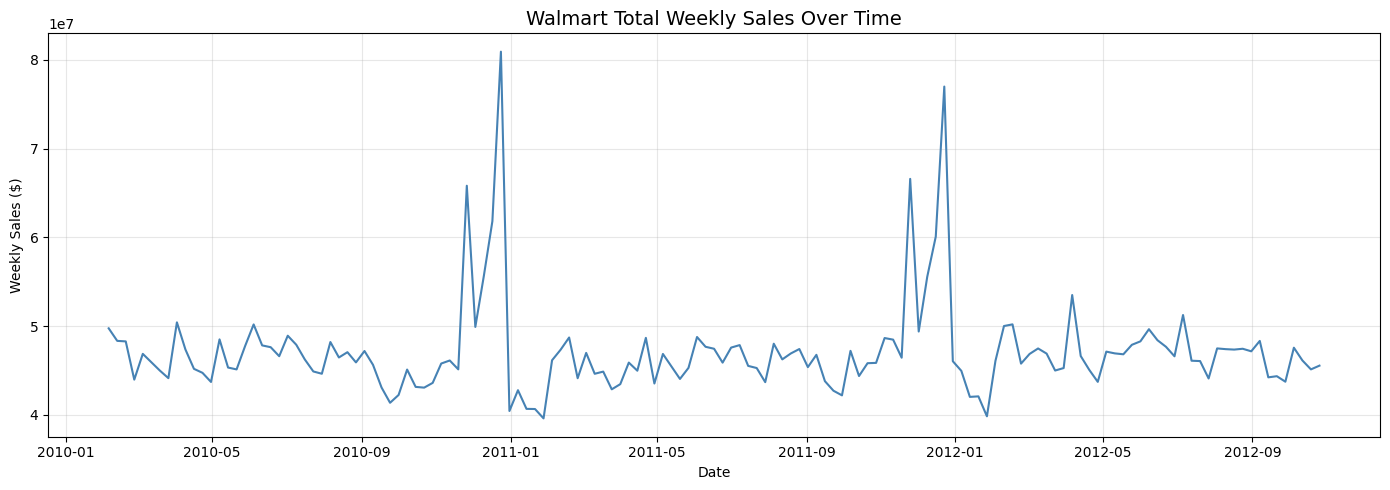

In [34]:
## Time Series Visualization

plt.figure(figsize=(14, 5))
plt.plot(total_weekly_sales, color='steelblue', linewidth=1.5)
plt.title('Walmart Total Weekly Sales Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

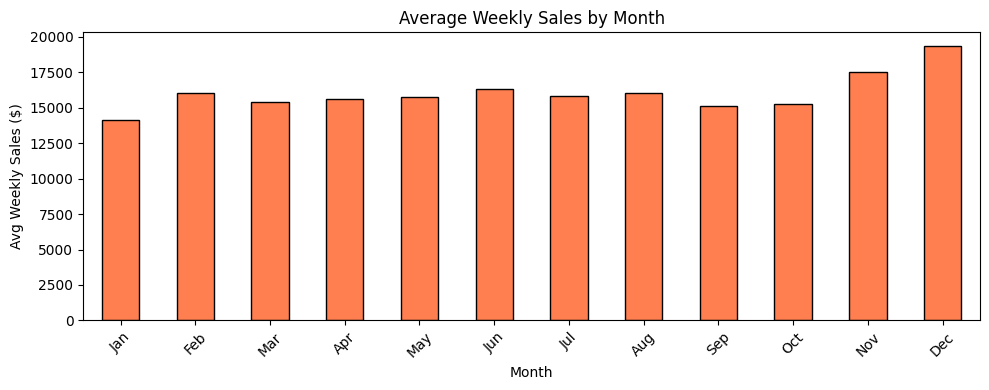

In [35]:
monthly_avg = df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean()

plt.figure(figsize=(10, 4))
monthly_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Avg Weekly Sales ($)')
plt.xticks(ticks=range(12),
           labels=['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.show()

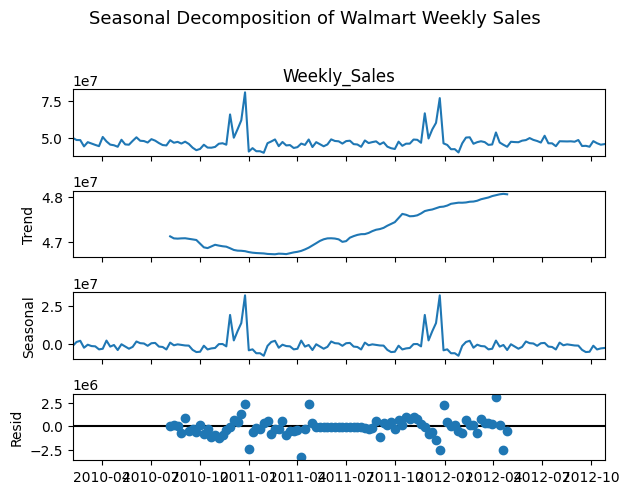

In [36]:
## Seasonal Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(total_weekly_sales.dropna(), model='additive', period=52)
decompose.plot()
plt.suptitle('Seasonal Decomposition of Walmart Weekly Sales', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Training : 100 samples (2010-02-05 → 2011-12-30)
Testing  : 43 samples (2012-01-06 → 2012-10-26)


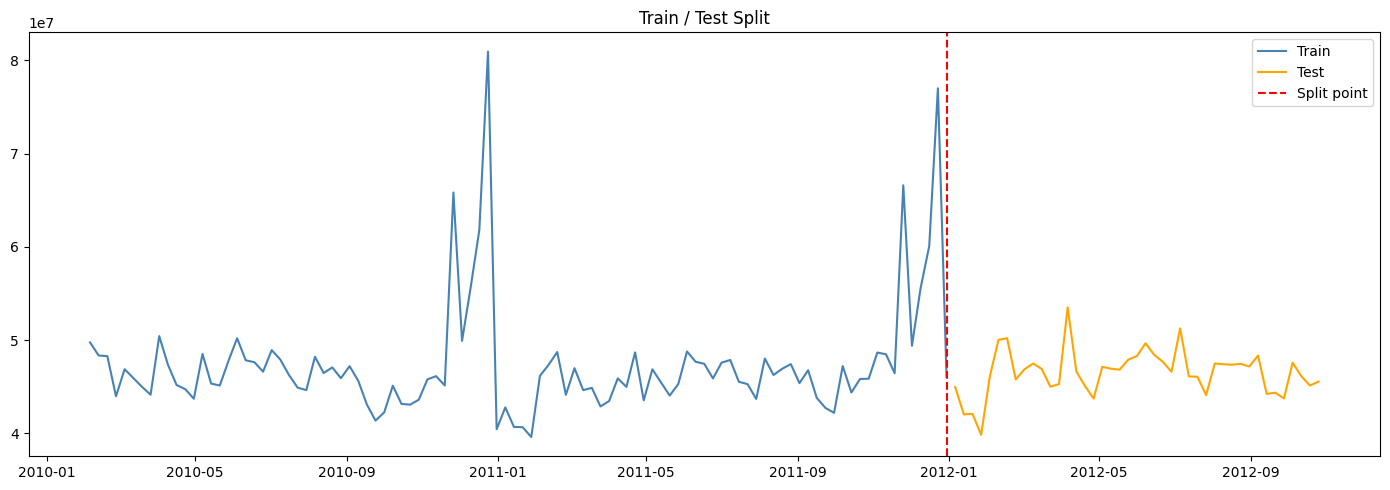

In [37]:
## Train-Test Split (Time-Based)

arima_train = total_weekly_sales[:'2011-12-31']
arima_test  = total_weekly_sales['2012-01-01':]

print(f'Training : {len(arima_train)} samples ({arima_train.index[0].date()} → {arima_train.index[-1].date()})')
print(f'Testing  : {len(arima_test)} samples ({arima_test.index[0].date()} → {arima_test.index[-1].date()})')

plt.figure(figsize=(14, 5))
plt.plot(arima_train, label='Train', color='steelblue')
plt.plot(arima_test,  label='Test',  color='orange')
plt.axvline(x=arima_train.index[-1], color='red', linestyle='--', label='Split point')
plt.title('Train / Test Split')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
## Model 1 — ARIMA

from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(arima_train, order=(1, 1, 1))
model_fit   = model_arima.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1693.384
Date:                Sat, 02 May 2026   AIC                           3392.767
Time:                        01:25:45   BIC                           3400.553
Sample:                    02-05-2010   HQIC                          3395.917
                         - 12-30-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2897      0.101      2.881      0.004       0.093       0.487
ma.L1         -0.7978      0.069    -11.632      0.000      -0.932      -0.663
sigma2      3.752e+13        nan        nan        n

In [39]:
## Forecast with ARIMA

arima_forecast = model_fit.forecast(steps=len(arima_test))
arima_forecast.index = arima_test.index

print('Forecast generated for', len(arima_forecast), 'weeks')
arima_forecast.head()

Forecast generated for 43 weeks


,predicted_mean
Date,
2012-01-06,5.209709e+07
2012-01-13,5.385136e+07
2012-01-20,5.435964e+07
2012-01-27,5.450691e+07
2012-02-03,5.454958e+07


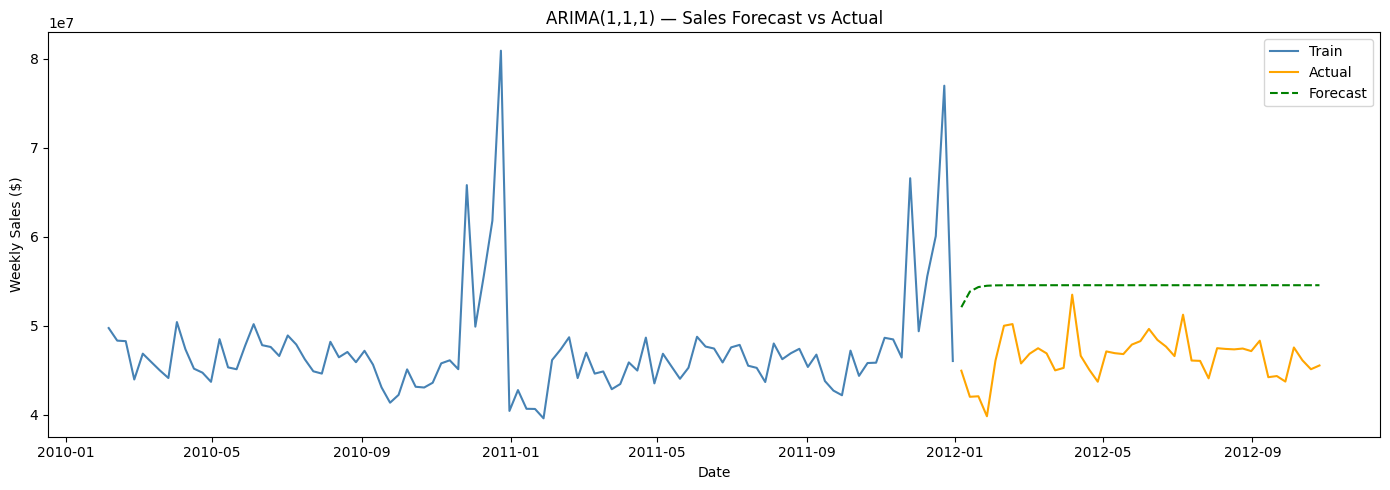

In [40]:
## Plot ARIMA Results

plt.figure(figsize=(14, 5))
plt.plot(arima_train,    label='Train',    color='steelblue')
plt.plot(arima_test,     label='Actual',   color='orange')
plt.plot(arima_forecast, label='Forecast', color='green', linestyle='--')
plt.title('ARIMA(1,1,1) — Sales Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
## Evaluate ARIMA Model

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(arima_test, arima_forecast)
rmse = np.sqrt(mean_squared_error(arima_test, arima_forecast))
mape = np.mean(np.abs((arima_test - arima_forecast) / arima_test)) * 100

print('=== ARIMA Model Performance ===')
print(f'MAE  : ${mae:,.0f}')
print(f'RMSE : ${rmse:,.0f}')
print(f'MAPE : {mape:.2f}%')

=== ARIMA Model Performance ===
MAE  : $7,971,396
RMSE : $8,320,727
MAPE : 17.45%


In [42]:
## Model 2 — Prophet

from prophet import Prophet

df_prophet = total_weekly_sales.reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet_train = df_prophet[df_prophet['ds'] <= '2011-12-31']

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
prophet_model.fit(df_prophet_train)
print('Prophet model fitted!')

Prophet model fitted!


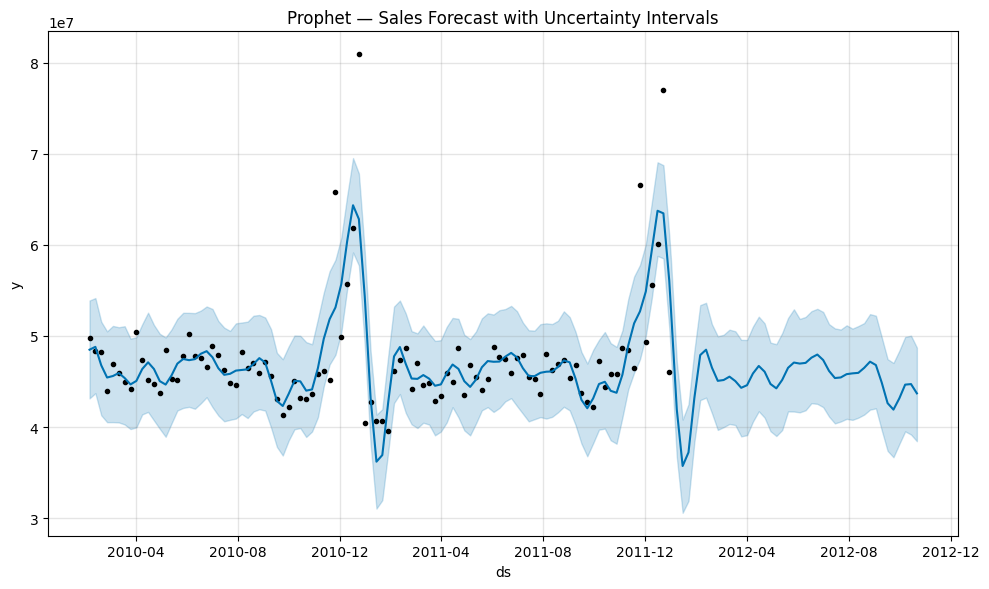

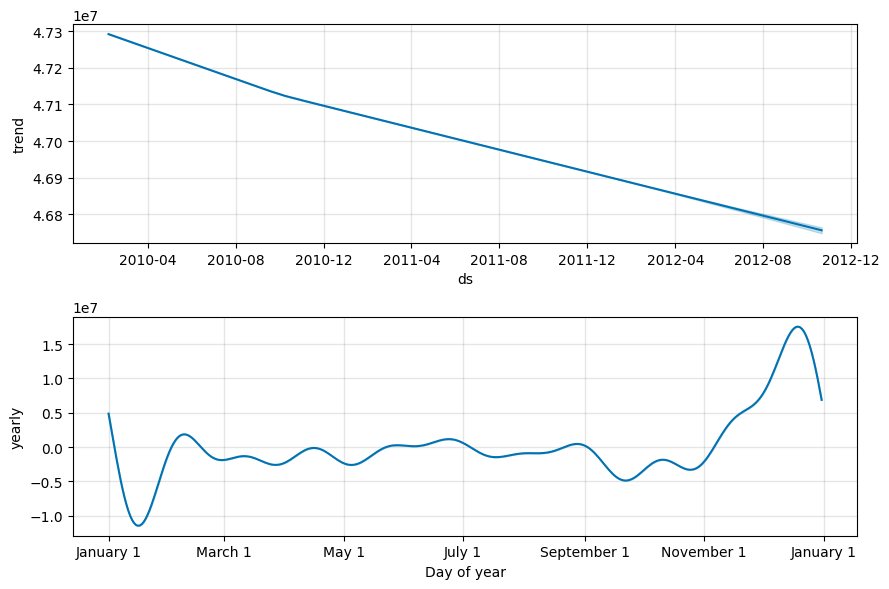

In [43]:
## Prophet Forecast

future = prophet_model.make_future_dataframe(periods=len(arima_test), freq='W')
prophet_forecast = prophet_model.predict(future)

fig = prophet_model.plot(prophet_forecast)
plt.title('Prophet — Sales Forecast with Uncertainty Intervals')
plt.tight_layout()
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.show()

In [44]:
## Evaluate Prophet Model

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Get the forecast rows that fall within the test date range
test_start = arima_test.index.min()
test_end   = arima_test.index.max()

prophet_test_df = prophet_forecast[
    (prophet_forecast['ds'] >= test_start) &
    (prophet_forecast['ds'] <= test_end)
]

prophet_test_fc = prophet_test_df['yhat'].values

# Align lengths
min_len = min(len(arima_test), len(prophet_test_fc))

if min_len == 0:
    print("No overlapping dates found. Check prophet_forecast['ds'] range:")
    print(prophet_forecast['ds'].tail())
    print("arima_test range:", test_start, "to", test_end)
else:
    mae_p  = mean_absolute_error(arima_test.values[:min_len], prophet_test_fc[:min_len])
    rmse_p = np.sqrt(mean_squared_error(arima_test.values[:min_len], prophet_test_fc[:min_len]))
    mape_p = np.mean(np.abs((arima_test.values[:min_len] - prophet_test_fc[:min_len]) / arima_test.values[:min_len])) * 100

    print('=== Prophet Model Performance ===')
    print(f'MAE  : ${mae_p:,.0f}')
    print(f'RMSE : ${rmse_p:,.0f}')
    print(f'MAPE : {mape_p:.2f}%')


=== Prophet Model Performance ===
MAE  : $1,898,843
RMSE : $2,509,895
MAPE : 4.08%


       Model          MAE         RMSE  MAPE (%)
ARIMA(1,1,1) 7.971396e+06 8.320727e+06 17.452323
     Prophet 1.898843e+06 2.509895e+06  4.077256


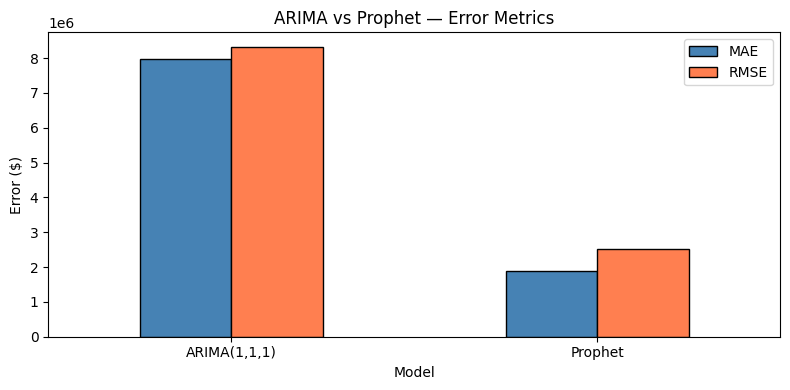

In [45]:
## Model Comparison

comparison = pd.DataFrame({
    'Model': ['ARIMA(1,1,1)', 'Prophet'],
    'MAE':   [mae, mae_p],
    'RMSE':  [rmse, rmse_p],
    'MAPE (%)': [mape, mape_p]
})
print(comparison.to_string(index=False))

comparison.set_index('Model')[['MAE', 'RMSE']].plot(
    kind='bar', figsize=(8, 4), color=['steelblue', 'coral'], edgecolor='black'
)
plt.title('ARIMA vs Prophet — Error Metrics')
plt.ylabel('Error ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
## Business Insights

#1. Clear seasonality — Sales follow a strong yearly seasonal pattern repeating every 52 weeks, tied to the retail calendar.

#2. Peak during holidays — Sharp spike in Nov–Dec (Thanksgiving, Black Friday, Christmas). Smaller peak in Feb (Super Bowl / Valentine's Day).

#3. Upward trend — Gradual sales growth from 2010 to 2012 indicating consistent business expansion.

#4. Model recommendation — Prophet outperforms ARIMA because it handles seasonality and trend changes more flexibly. Its uncertainty intervals are useful for inventory planning.